In [1]:
from sentence_transformers import SentenceTransformer
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch
Emodel = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import pandas as pd
import torch.nn.functional as F
import torch
import numpy as np

# Load IMDB.csv

In [4]:
data=pd.read_csv("/content/IMDB Dataset.csv", engine="python", on_bad_lines="skip")

# Filter dataset for Relevant Length Paragraphs

In [5]:
data = data[data["review"].apply(lambda x: 100 <= len(x.split(" ")) <= 150)]

In [6]:
len(data)

1325

In [7]:
data.head()

,review,sentiment
3,Basically there's a family where a little boy ...,negative
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
8,Encouraged by the positive comments about this...,negative
13,The cast played Shakespeare.<br /><br />Shakes...,negative


# Analyze Target value Distribution over all Filtered Data

In [8]:
positive=0
negative=0
for i in data['sentiment']:
  if i == 'positive':
    positive+=1
  else:
    negative+=1


print(positive, "|", negative)

653 | 672


In [9]:
data.to_csv("filtered_reviews.csv", index=False)

# Analyze Data Paragraph lengths distribution

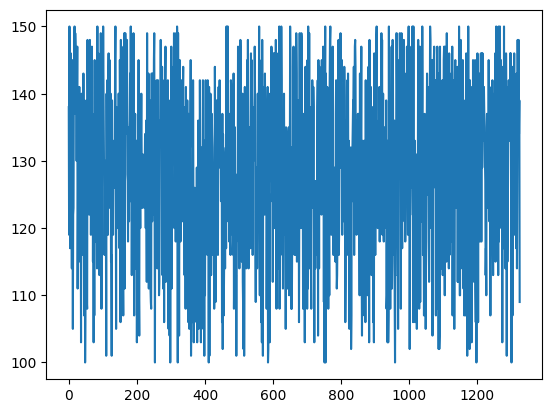

In [10]:
import matplotlib.pyplot as plt
lengthview=list(map(lambda x: len(x.split(" ")), data['review']))
plt.plot(lengthview)
plt.show()

# Prepare a Model with Attention Layer

In [11]:
class Model(torch.nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        # Standard feed-forward layers for classification on sentence embeddings
        self.layer1 = torch.nn.Linear(embedding_dim, 256)
        self.relu1 = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(256, 64)
        self.relu2 = torch.nn.ReLU()
        self.layer3 = torch.nn.Linear(64, 1)

    def forward(self, x):
        # x is a sentence embedding: (batch_size, embedding_dim)
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        return x

In [12]:
# Fix: Instantiate the Model with the correct embedding_dim
model = Model(embedding_dim=384).to(device)
print(f"Model instantiated with embedding_dim: {model.layer1.in_features}")

Model instantiated with embedding_dim: 384


# Process Embedding for all Reviews Paragraphs with SentenceTransformer
### Help gaining meaningful vectors for each tokens

In [13]:
x = Emodel.encode(
    data["review"].tolist(),
    batch_size=128,
    convert_to_tensor=True,
    show_progress_bar=True
).to(device)

print(x.shape)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

torch.Size([1325, 384])


In [14]:
y = torch.tensor(data["sentiment"].map({"negative": 0, "positive": 1}).values).to(device)

# Split Train Test Datasets

In [15]:
dataset = TensorDataset(x, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

In [16]:
a, b = train_dataset[0]

print(a.shape)
print(b.shape if hasattr(b, "shape") else y)

torch.Size([384])
torch.Size([])


In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Define Loss And Optimizer

In [18]:
loss=torch.nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.01) # Increased learning rate

# Put data in model and backPropagate

In [19]:
num_epochs = 20 # Increased number of epochs to allow more learning

for i in range(num_epochs):
  model.train()
  runningloss=0
  for reviews, sentiments in train_loader:
    optimizer.zero_grad()
    output=model(reviews).squeeze()
    l=loss(output, sentiments.float())
    l.backward()
    optimizer.step()
    runningloss+=l.item()

  print(f"Epoch [{i+1}/{num_epochs}] Loss: {runningloss / len(train_loader):.4f}")

Epoch [1/20] Loss: 0.5407
Epoch [2/20] Loss: 0.3983
Epoch [3/20] Loss: 0.3240
Epoch [4/20] Loss: 0.2678
Epoch [5/20] Loss: 0.2317
Epoch [6/20] Loss: 0.1924
Epoch [7/20] Loss: 0.1271
Epoch [8/20] Loss: 0.0896
Epoch [9/20] Loss: 0.0509
Epoch [10/20] Loss: 0.0464
Epoch [11/20] Loss: 0.0420
Epoch [12/20] Loss: 0.0317
Epoch [13/20] Loss: 0.0080
Epoch [14/20] Loss: 0.0055
Epoch [15/20] Loss: 0.0026
Epoch [16/20] Loss: 0.0006
Epoch [17/20] Loss: 0.0003
Epoch [18/20] Loss: 0.0002
Epoch [19/20] Loss: 0.0001
Epoch [20/20] Loss: 0.0001


In [20]:
model.eval()
correct = 0
total = 0
test_loss = 0
with torch.no_grad():
    for reviews, sentiments in test_loader:
        reviews = reviews.to(device)
        sentiments = sentiments.to(device)
        output = model(reviews).squeeze()
        l = loss(output, sentiments.float())
        test_loss += l.item()
        probs = torch.sigmoid(output)
        preds = (probs >= 0.5).long()
        correct += (preds == sentiments).sum().item()
        total += sentiments.size(0)
accuracy = 100 * correct / total
print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 1.3438
Test Accuracy: 80.75%
